# Lab Assignment 4 — Two Sample T-Test
**Course:** Simulation & Modeling Lab

**Name:** MD Shoaibe Hasan

**Student ID:** 0432220005101083

**Department:** Computer Science and Engineering, UITS

## Step 0 — Import Libraries and Load Data

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.set_printoptions(precision=4, suppress=True)

data1 = np.array([18.4, 19.1, 17.9, 18.7, 18.3])
data2 = np.array([20.2, 20.5, 20.1, 20.3, 20.4])
alpha = 0.05

print("Data 1 :", data1)
print("Data 2 :", data2)
print("Alpha  :", alpha)

Data 1 : [18.4 19.1 17.9 18.7 18.3]
Data 2 : [20.2 20.5 20.1 20.3 20.4]
Alpha  : 0.05


---
## Task 1 — State the Hypotheses

Let mu1 be the population mean of Group 1 and mu2 be the population mean of Group 2.

- **Null hypothesis (H0):** mu1 = mu2  — the two population means are equal (there is no real difference between the groups)
- **Alternative hypothesis (H1):** mu1 != mu2  — the two population means are different

This is a **two-tailed test**, because we only ask *whether* the means differ, not which one is larger. The test is run at a significance level of **alpha = 0.05**.

---
## Task 2 — Sample Means, Sample Variances (ddof = 1), and Mean Difference

`ddof = 1` gives the **sample** variance (dividing by n-1 instead of n), which is the unbiased estimator we need for a t-test.

In [11]:
n1, n2 = data1.size, data2.size

mean1, mean2 = data1.mean(), data2.mean()
var1 = data1.var(ddof=1)
var2 = data2.var(ddof=1)
sd1, sd2 = np.sqrt(var1), np.sqrt(var2)
mean_diff = mean1 - mean2

print(f"{'Statistic':<22}{'Group 1':>12}{'Group 2':>12}")
print("-" * 46)
print(f"{'Sample size (n)':<22}{n1:>12}{n2:>12}")
print(f"{'Sample mean':<22}{mean1:>12.4f}{mean2:>12.4f}")
print(f"{'Sample variance (s^2)':<22}{var1:>12.4f}{var2:>12.4f}")
print(f"{'Sample std dev (s)':<22}{sd1:>12.4f}{sd2:>12.4f}")
print("-" * 46)
print(f"Mean difference (mean1 - mean2) = {mean_diff:.4f}")

Statistic                  Group 1     Group 2
----------------------------------------------
Sample size (n)                  5           5
Sample mean                18.4800     20.3000
Sample variance (s^2)       0.2020      0.0250
Sample std dev (s)          0.4494      0.1581
----------------------------------------------
Mean difference (mean1 - mean2) = -1.8200


---
## Task 3 — t-statistic, Degrees of Freedom, and Two-tailed p-value

Since both samples are the same size and their variances are similar, we use the **pooled (Student's) two-sample t-test**:

$$s_p^2 = \frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}, \qquad
t = \frac{\bar{x}_1 - \bar{x}_2}{s_p\sqrt{\frac{1}{n_1}+\frac{1}{n_2}}}, \qquad
df = n_1 + n_2 - 2$$

In [12]:
# --- Manual calculation ---
pooled_var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
pooled_sd = np.sqrt(pooled_var)
se_diff = pooled_sd * np.sqrt(1 / n1 + 1 / n2)

df = n1 + n2 - 2
t_manual = mean_diff / se_diff
p_manual = 2 * stats.t.sf(abs(t_manual), df)

print("Pooled variance (sp^2)      :", round(pooled_var, 6))
print("Pooled std deviation (sp)   :", round(pooled_sd, 6))
print("Standard error of difference:", round(se_diff, 6))
print("Degrees of freedom (df)     :", df)
print("-" * 45)
print("t-statistic (manual)        :", round(t_manual, 4))
print("Two-tailed p-value (manual) :", p_manual)

Pooled variance (sp^2)      : 0.1135
Pooled std deviation (sp)   : 0.336898
Standard error of difference: 0.213073
Degrees of freedom (df)     : 8
---------------------------------------------
t-statistic (manual)        : -8.5417
Two-tailed p-value (manual) : 2.7168142710641727e-05


In [13]:
# --- Verification using SciPy ---
t_stat, p_value = stats.ttest_ind(data1, data2, equal_var=True)

print("t-statistic (scipy)        :", round(t_stat, 4))
print("Two-tailed p-value (scipy) :", p_value)
print("\nManual and SciPy results match:",
      np.isclose(t_manual, t_stat) and np.isclose(p_manual, p_value))

# Welch's test shown only as a cross-check (does not assume equal variances)
t_w, p_w = stats.ttest_ind(data1, data2, equal_var=False)
print("\n[Cross-check] Welch t-test  : t =", round(t_w, 4), ", p =", p_w)

t-statistic (scipy)        : -8.5417
Two-tailed p-value (scipy) : 2.7168142710641727e-05

Manual and SciPy results match: True

[Cross-check] Welch t-test  : t = -8.5417 , p = 0.0003711295308672951


---
## Task 4 — 95% Confidence Interval for the Mean Difference

$$CI = (\bar{x}_1 - \bar{x}_2) \pm t_{crit} \times SE$$

where `t_crit` is the two-tailed critical value at alpha = 0.05 with df = 8.

In [14]:
t_crit = stats.t.ppf(1 - alpha / 2, df)
margin = t_crit * se_diff
ci_low = mean_diff - margin
ci_high = mean_diff + margin

print("Critical t value (df=8, two-tailed) :", round(t_crit, 4))
print("Margin of error                     :", round(margin, 4))
print("-" * 52)
print(f"95% Confidence Interval for (mu1 - mu2):")
print(f"    [ {ci_low:.4f} , {ci_high:.4f} ]")
print("-" * 52)
print("Does the interval contain 0 ?      :", ci_low <= 0 <= ci_high)

Critical t value (df=8, two-tailed) : 2.306
Margin of error                     : 0.4913
----------------------------------------------------
95% Confidence Interval for (mu1 - mu2):
    [ -2.3113 , -1.3287 ]
----------------------------------------------------
Does the interval contain 0 ?      : False


---
## Task 5 — Decision

In [15]:
print("t-statistic      :", round(t_stat, 4))
print("Critical value   : +/-", round(t_crit, 4))
print("p-value          :", p_value)
print("Alpha            :", alpha)
print("=" * 55)

if p_value < alpha:
    print("p-value < alpha  ->  REJECT the null hypothesis (H0)")
    print("The two population means ARE significantly different.")
else:
    print("p-value > alpha  ->  FAIL TO REJECT the null hypothesis (H0)")
    print("Not enough evidence that the population means differ.")

print("\nSame conclusion from the confidence interval:")
if ci_low <= 0 <= ci_high:
    print("  The 95% CI contains 0  ->  no significant difference.")
else:
    print("  The 95% CI does NOT contain 0  ->  significant difference.")

t-statistic      : -8.5417
Critical value   : +/- 2.306
p-value          : 2.7168142710641727e-05
Alpha            : 0.05
p-value < alpha  ->  REJECT the null hypothesis (H0)
The two population means ARE significantly different.

Same conclusion from the confidence interval:
  The 95% CI does NOT contain 0  ->  significant difference.


### Visualization

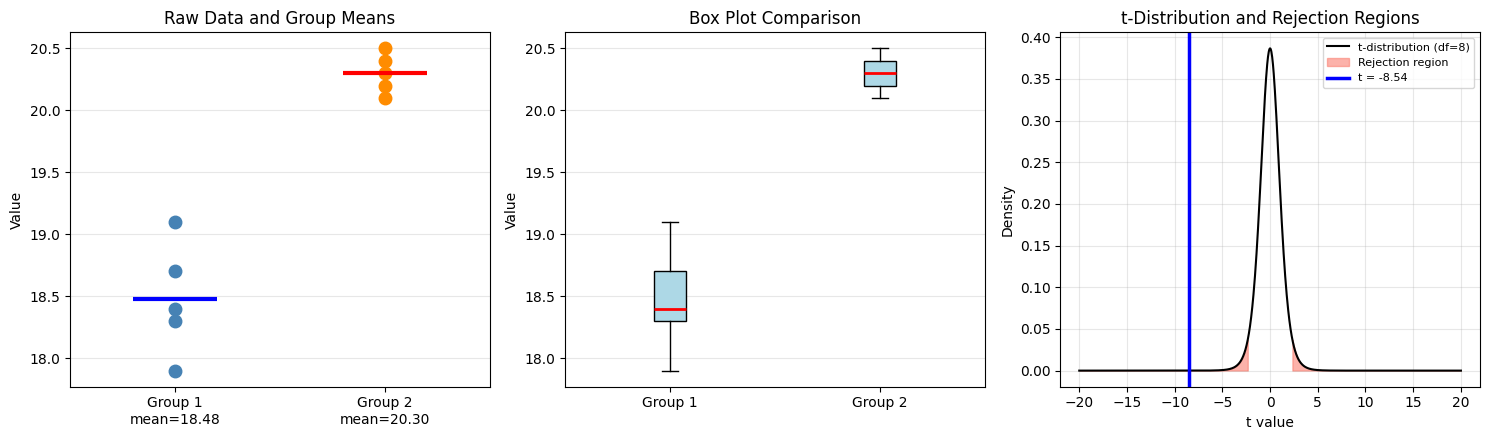

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))

# --- 1. Raw data points with group means ---
ax[0].plot(np.ones(n1), data1, "o", color="steelblue", markersize=9, label="Group 1")
ax[0].plot(np.ones(n2) * 2, data2, "o", color="darkorange", markersize=9, label="Group 2")
ax[0].hlines(mean1, 0.8, 1.2, color="blue", linewidth=3)
ax[0].hlines(mean2, 1.8, 2.2, color="red", linewidth=3)
ax[0].set_xticks([1, 2])
ax[0].set_xticklabels([f"Group 1\nmean={mean1:.2f}", f"Group 2\nmean={mean2:.2f}"])
ax[0].set_xlim(0.5, 2.5)
ax[0].set_title("Raw Data and Group Means")
ax[0].set_ylabel("Value")
ax[0].grid(axis="y", alpha=0.3)

# --- 2. Box plot ---
ax[1].boxplot([data1, data2], patch_artist=True,
              boxprops=dict(facecolor="lightblue"),
              medianprops=dict(color="red", linewidth=2))
ax[1].set_xticks([1, 2])
ax[1].set_xticklabels(["Group 1", "Group 2"])
ax[1].set_title("Box Plot Comparison")
ax[1].set_ylabel("Value")
ax[1].grid(axis="y", alpha=0.3)

# --- 3. t-distribution with rejection regions ---
x = np.linspace(-20, 20, 1000)
y = stats.t.pdf(x, df)
ax[2].plot(x, y, color="black", linewidth=1.5, label=f"t-distribution (df={df})")
ax[2].fill_between(x, y, where=(x <= -t_crit), color="salmon", alpha=0.6)
ax[2].fill_between(x, y, where=(x >= t_crit), color="salmon", alpha=0.6,
                   label="Rejection region")
ax[2].axvline(t_stat, color="blue", linewidth=2.5, label=f"t = {t_stat:.2f}")
ax[2].set_title("t-Distribution and Rejection Regions")
ax[2].set_xlabel("t value")
ax[2].set_ylabel("Density")
ax[2].legend(fontsize=8)
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

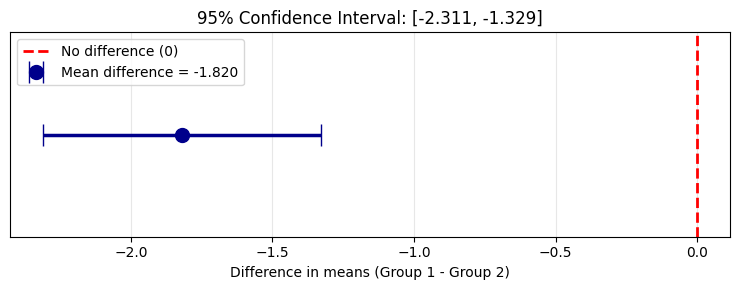

In [17]:
plt.figure(figsize=(7.5, 3))
plt.errorbar(mean_diff, 0, xerr=margin, fmt="o", color="darkblue",
             markersize=10, capsize=8, linewidth=2.5,
             label=f"Mean difference = {mean_diff:.3f}")
plt.axvline(0, color="red", linestyle="--", linewidth=2, label="No difference (0)")
plt.yticks([])
plt.xlabel("Difference in means (Group 1 - Group 2)")
plt.title(f"95% Confidence Interval: [{ci_low:.3f}, {ci_high:.3f}]")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation in Plain English

Group 1 has an average of about **18.48** while Group 2 averages **20.30**, a gap of roughly **-1.82**. The t-statistic is about **-8.54** with a p-value of roughly **0.0000272**, which is far below the 0.05 cut-off, so we **reject the null hypothesis**.

In plain words: the two groups really are different — the gap between them is far too large to be explained by random chance, especially since the readings inside each group are tightly clustered. The 95% confidence interval for the difference runs from about **-2.31 to -1.33** and never touches zero, which tells us the same thing and adds that Group 1's true mean is somewhere between 1.3 and 2.3 units lower than Group 2's.

---

## Summary Table

In [18]:
print("=" * 52)
print("           TWO SAMPLE T-TEST SUMMARY")
print("=" * 52)
print(f"{'H0':<28}: mu1 = mu2")
print(f"{'H1':<28}: mu1 != mu2")
print(f"{'Sample mean 1':<28}: {mean1:.4f}")
print(f"{'Sample mean 2':<28}: {mean2:.4f}")
print(f"{'Sample variance 1 (ddof=1)':<28}: {var1:.4f}")
print(f"{'Sample variance 2 (ddof=1)':<28}: {var2:.4f}")
print(f"{'Mean difference':<28}: {mean_diff:.4f}")
print(f"{'Pooled std deviation':<28}: {pooled_sd:.4f}")
print(f"{'Standard error':<28}: {se_diff:.4f}")
print(f"{'t-statistic':<28}: {t_stat:.4f}")
print(f"{'Degrees of freedom':<28}: {df}")
print(f"{'Two-tailed p-value':<28}: {p_value:.10f}")
print(f"{'95% CI for difference':<28}: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"{'Significance level':<28}: {alpha}")
print(f"{'Decision':<28}: {'REJECT H0' if p_value < alpha else 'FAIL TO REJECT H0'}")
print("=" * 52)

           TWO SAMPLE T-TEST SUMMARY
H0                          : mu1 = mu2
H1                          : mu1 != mu2
Sample mean 1               : 18.4800
Sample mean 2               : 20.3000
Sample variance 1 (ddof=1)  : 0.2020
Sample variance 2 (ddof=1)  : 0.0250
Mean difference             : -1.8200
Pooled std deviation        : 0.3369
Standard error              : 0.2131
t-statistic                 : -8.5417
Degrees of freedom          : 8
Two-tailed p-value          : 0.0000271681
95% CI for difference       : [-2.3113, -1.3287]
Significance level          : 0.05
Decision                    : REJECT H0
